In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, classification_report

from google.colab import files


In [3]:
import zipfile
import os
import glob
import shutil

def handle_zip(fname, expected_ext):
    with zipfile.ZipFile(fname, "r") as z:
        names = z.namelist()

    npy_like = all(n.endswith(".npy") for n in names) and len(names) > 0
    if expected_ext == ".npz" and npy_like:
        new_name = fname.rsplit(".zip", 1)[0]
        if not new_name.endswith(".npz"):
            new_name = new_name.rsplit("_npz", 1)[0] + ".npz" if new_name.endswith("_npz") else new_name + ".npz"
        shutil.copy(fname, new_name)
        print(f"  {fname} looks like a mis-named .npz (contains {names}) - saved as {new_name}")
        return new_name

    extract_dir = f"_extracted_{fname[:-4]}"
    with zipfile.ZipFile(fname, "r") as z:
        z.extractall(extract_dir)
        print(f"  Extracted from {fname}: {names}")
    return None

print("Upload ALL your .npz prediction files togethe:")
uploaded_npz_raw = files.upload()

for fname in list(uploaded_npz_raw.keys()):
    if fname.lower().endswith(".zip"):
        handle_zip(fname, ".npz")

npz_files = []
for path in glob.glob("**/*.npz", recursive=True):
    flat_name = os.path.basename(path)
    if path != flat_name:
        shutil.copy(path, flat_name)
    if flat_name not in npz_files:
        npz_files.append(flat_name)

print("\nAvailable .npz files:", npz_files)

print("\nUpload ALL your .json results/history files together:")
uploaded_json_raw = files.upload()

for fname in list(uploaded_json_raw.keys()):
    if fname.lower().endswith(".zip"):
        extract_dir = f"_extracted_{fname[:-4]}"
        with zipfile.ZipFile(fname, "r") as z:
            z.extractall(extract_dir)
            print(f"Extracted from {fname}: {z.namelist()}")

json_files = []
for path in glob.glob("**/*.json", recursive=True):
    flat_name = os.path.basename(path)
    if path != flat_name:
        shutil.copy(path, flat_name)
    if flat_name not in json_files:
        json_files.append(flat_name)

print("\nAvailable .json files:", json_files)

Upload ALL your .npz prediction files togethe:


Saving nfnet_frozenFalse_lossce_test_predictions (1).npz.zip to nfnet_frozenFalse_lossce_test_predictions (1).npz.zip
Saving dinov2_frozenFalse_weightsFalse_test_predictions.npz to dinov2_frozenFalse_weightsFalse_test_predictions.npz
Saving regnety_400mf_baseline_test_predictions.npz to regnety_400mf_baseline_test_predictions.npz
Saving convnext_tiny_test_predictions.npz to convnext_tiny_test_predictions.npz
  nfnet_frozenFalse_lossce_test_predictions (1).npz.zip looks like a mis-named .npz (contains ['preds.npy', 'labels.npy', 'class_names.npy']) - saved as nfnet_frozenFalse_lossce_test_predictions (1).npz

Available .npz files: ['convnext_tiny_test_predictions.npz', 'regnety_400mf_baseline_test_predictions.npz', 'nfnet_frozenFalse_lossce_test_predictions (1).npz', 'dinov2_frozenFalse_weightsFalse_test_predictions.npz']

Upload ALL your .json results/history files together:


Saving nfnet_frozenFalse_lossce_results (1).json to nfnet_frozenFalse_lossce_results (1).json
Saving dinov2_frozenFalse_weightsFalse_results (1).json to dinov2_frozenFalse_weightsFalse_results (1).json
Saving regnety_400mf_baseline_history.json to regnety_400mf_baseline_history.json
Saving convnext_tiny_history (1).json to convnext_tiny_history (1).json

Available .json files: ['nfnet_frozenFalse_lossce_results (1).json', 'convnext_tiny_history (1).json', 'dinov2_frozenFalse_weightsFalse_results (1).json', 'regnety_400mf_baseline_history.json', 'anscombe.json']


In [4]:
MODEL_KEYWORDS = {
    "Baseline (RegNetY)": "regnety",
    "ConvNeXt-Tiny":"convnext",
    "DINOv2":"dinov2",
    "NFNet":"nfnet",
}

def find_file(keyword, filenames):
    matches = [f for f in filenames if keyword.lower() in f.lower()]
    return matches[0] if matches else None

model_files = {}
for model_name, kw in MODEL_KEYWORDS.items():
    npz_path = find_file(kw, npz_files)
    json_path = find_file(kw, json_files)
    model_files[model_name] = {"npz": npz_path, "json": json_path}
    status = "OK" if npz_path else "MISSING npz"
    print(f"{model_name:22s} - npz: {npz_path or '(none)'}  |  json: {json_path or '(none)'}  [{status}]")

Baseline (RegNetY)     - npz: regnety_400mf_baseline_test_predictions.npz  |  json: regnety_400mf_baseline_history.json  [OK]
ConvNeXt-Tiny          - npz: convnext_tiny_test_predictions.npz  |  json: convnext_tiny_history (1).json  [OK]
DINOv2                 - npz: dinov2_frozenFalse_weightsFalse_test_predictions.npz  |  json: dinov2_frozenFalse_weightsFalse_results (1).json  [OK]
NFNet                  - npz: nfnet_frozenFalse_lossce_test_predictions (1).npz  |  json: nfnet_frozenFalse_lossce_results (1).json  [OK]


In [5]:
#  Load predictions and results for every model that has an npz file
model_data = {}

for model_name, paths in model_files.items():
    if paths["npz"] is None:
        continue
    npz = np.load(paths["npz"], allow_pickle=True)
    preds = npz["preds"]
    labels = npz["labels"]
    class_names = list(npz["class_names"])

    results = None
    if paths["json"] is not None:
        with open(paths["json"]) as f:
            results = json.load(f)

    cm = confusion_matrix(labels, preds, labels=range(len(class_names)))
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="weighted", zero_division=0)

    model_data[model_name] = {
        "preds": preds, "labels": labels, "class_names": class_names,
        "cm": cm, "accuracy": (preds == labels).mean(),
        "precision": precision, "recall": recall, "f1": f1,
        "results": results,
    }

print(f"Loaded {len(model_data)} models: {list(model_data.keys())}")

Loaded 4 models: ['Baseline (RegNetY)', 'ConvNeXt-Tiny', 'DINOv2', 'NFNet']


## 1. Headline comparison table

In [6]:
summary_rows = []
for name, d in model_data.items():
    summary_rows.append({
        "Model": name,
        "Accuracy": f"{d['accuracy']*100:.2f}%",
        "Precision": f"{d['precision']*100:.2f}%",
        "Recall": f"{d['recall']*100:.2f}%",
        "F1 (weighted)": f"{d['f1']*100:.2f}%",
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Model,Accuracy,Precision,Recall,F1 (weighted)
0,Baseline (RegNetY),65.31%,67.76%,65.31%,64.40%
1,ConvNeXt-Tiny,78.21%,80.31%,78.21%,78.29%
2,DINOv2,83.17%,83.26%,83.17%,83.02%
3,NFNet,79.30%,79.51%,79.30%,79.10%


## 2. Training curves overlay (validation accuracy)



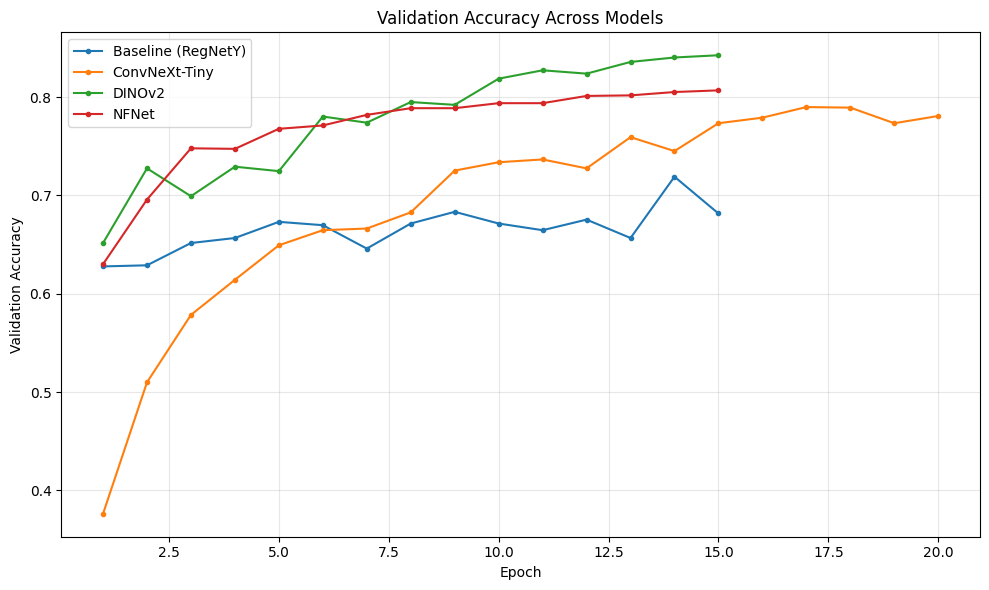

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

for name, d in model_data.items():
    results = d["results"]
    if results is None:
        continue
    history = results.get("history", results)
    val_acc = history.get("val_acc")
    if val_acc:
        ax.plot(range(1, len(val_acc) + 1), val_acc, marker="o", markersize=3, label=name)

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Accuracy")
ax.set_title("Validation Accuracy Across Models")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("comparison_training_curves.png", dpi=150)
plt.show()

## 3. Side-by-side confusion matrices

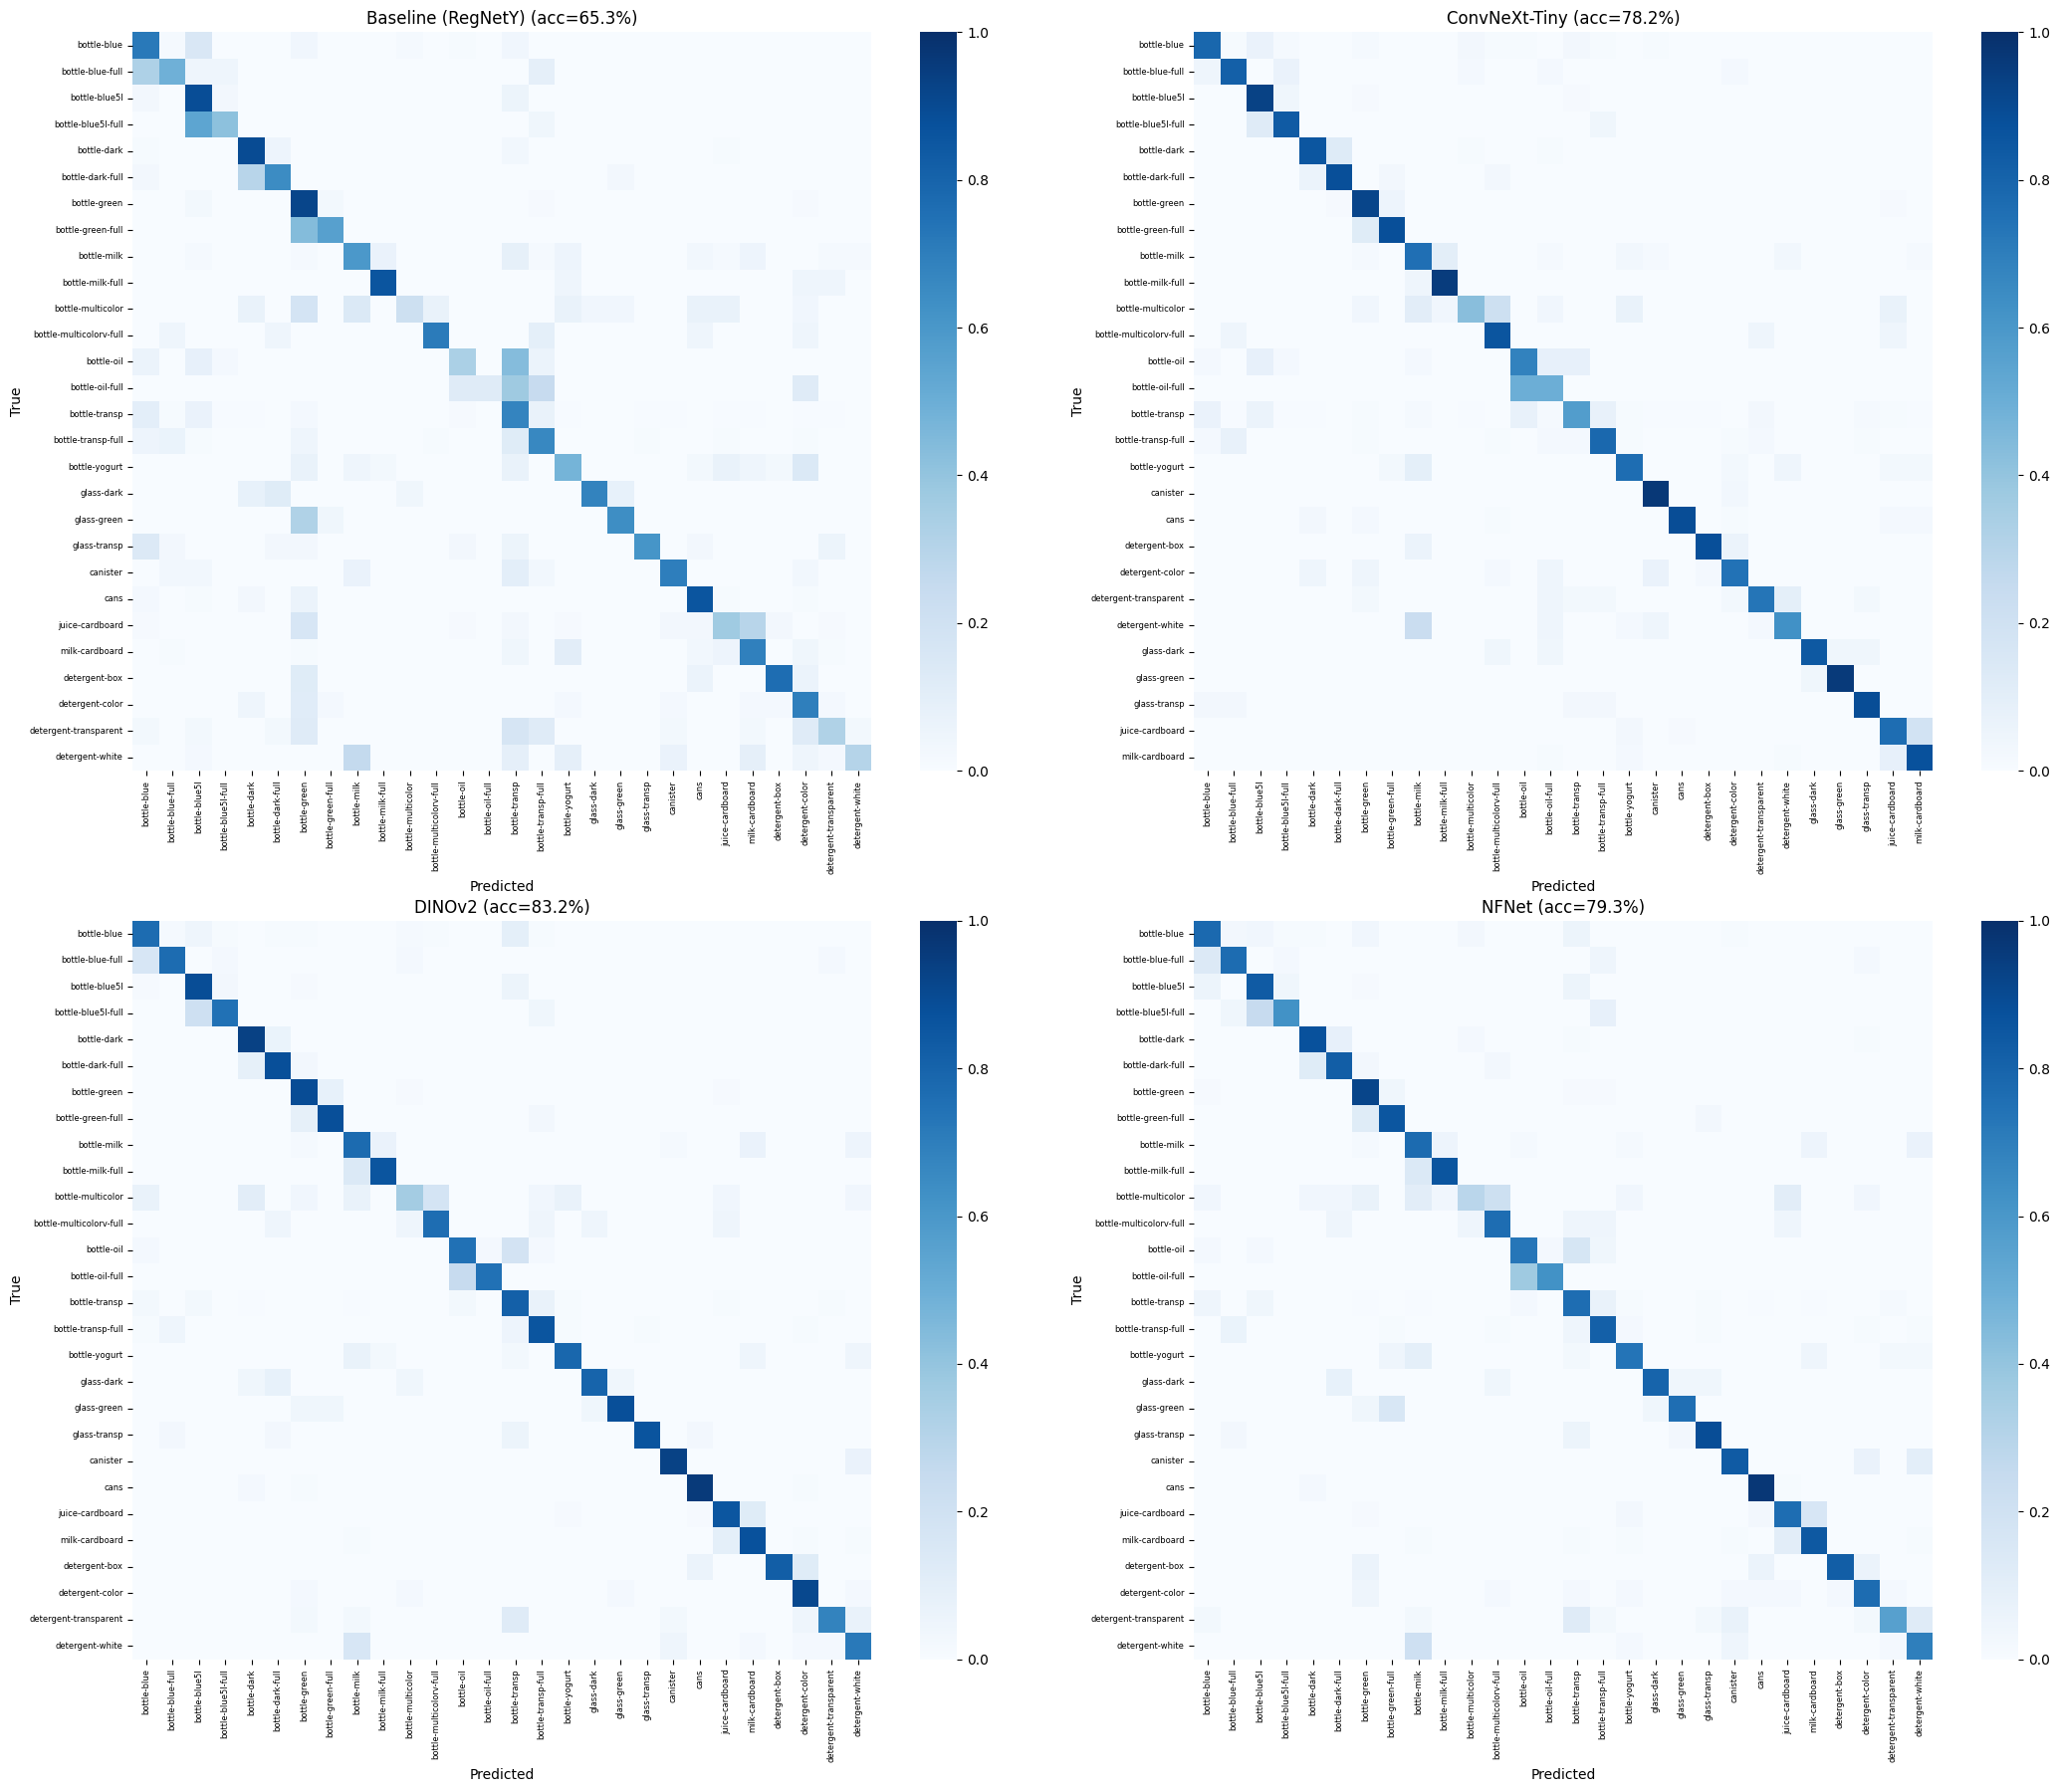

In [8]:
n = len(model_data)
ncols = 2
nrows = (n + 1) // 2
fig, axes = plt.subplots(nrows, ncols, figsize=(11 * ncols, 9 * nrows))
axes = np.array(axes).flatten()

for ax, (name, d) in zip(axes, model_data.items()):
    cm_norm = d["cm"].astype(float) / (d["cm"].sum(axis=1, keepdims=True) + 1e-6)
    sns.heatmap(cm_norm, ax=ax, cmap="Blues", cbar=True, square=True,
                xticklabels=d["class_names"], yticklabels=d["class_names"],
                vmin=0, vmax=1)
    ax.set_title(f"{name} (acc={d['accuracy']*100:.1f}%)", fontsize=12)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.tick_params(axis="both", labelsize=6)
    plt.setp(ax.get_xticklabels(), rotation=90)

for ax in axes[len(model_data):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("comparison_confusion_matrices.png", dpi=150)
plt.show()

## 4. Per-class F1 comparison across models

Classes at the top (highest variance across models) are where model
choice matters most.

In [9]:
reference_classes = next(iter(model_data.values()))["class_names"]

f1_table = {}
for name, d in model_data.items():
    _, _, per_class_f1, _ = precision_recall_fscore_support(
        d["labels"], d["preds"], average=None, zero_division=0,
        labels=range(len(d["class_names"]))
    )
    f1_table[name] = dict(zip(d["class_names"], per_class_f1))

f1_df = pd.DataFrame(f1_table)
f1_df["variance_across_models"] = f1_df.var(axis=1)
f1_df_sorted = f1_df.sort_values("variance_across_models", ascending=False)

pd.set_option("display.float_format", lambda x: f"{x:.3f}")
f1_df_sorted

,Baseline (RegNetY),ConvNeXt-Tiny,DINOv2,NFNet,variance_across_models
bottle-oil-full,0.222,0.235,0.800,0.714,0.094
juice-cardboard,0.463,0.759,0.829,0.765,0.027
detergent-transparent,0.413,0.732,0.767,0.648,0.025
bottle-oil,0.451,0.635,0.783,0.761,0.023
bottle-yogurt,0.471,0.744,0.815,0.738,0.023
bottle-blue5l-full,0.500,0.741,0.783,0.682,0.016
detergent-white,0.448,0.684,0.713,0.682,0.015
bottle-blue-full,0.538,0.787,0.795,0.759,0.015
bottle-green,0.624,0.855,0.868,0.845,0.014
detergent-color,0.600,0.780,0.867,0.786,0.013


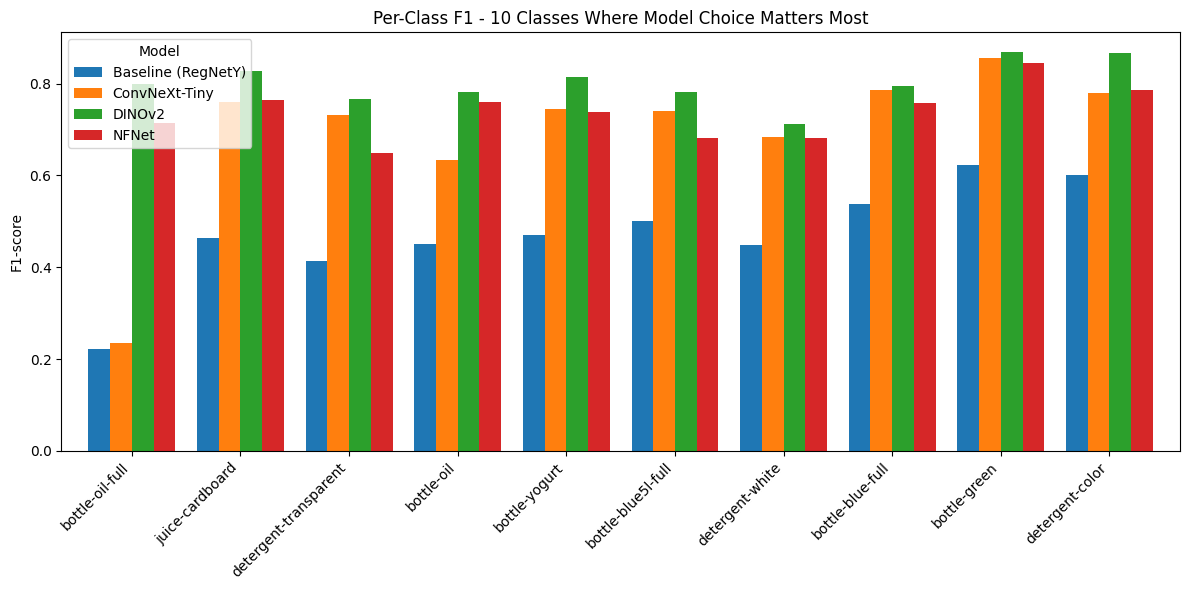

In [10]:
# Visualise the per-class F1 comparison as a grouped bar chart for the
# 10 classes with the highest variance across models
top_variance_classes = f1_df_sorted.head(10).index.tolist()
plot_df = f1_df.loc[top_variance_classes, list(model_data.keys())]

fig, ax = plt.subplots(figsize=(12, 6))
plot_df.plot(kind="bar", ax=ax, width=0.8)
ax.set_ylabel("F1-score")
ax.set_title("Per-Class F1 - 10 Classes Where Model Choice Matters Most")
ax.legend(title="Model")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("comparison_per_class_f1_top_variance.png", dpi=150)
plt.show()

## 5. Most-confused class pairs, per model

In [11]:
def top_confused_pairs(cm, class_names, top_k=5):
    cm_copy = cm.copy().astype(float)
    np.fill_diagonal(cm_copy, 0)
    flat_idx = np.argsort(cm_copy.flatten())[::-1][:top_k]
    pairs = []
    for idx in flat_idx:
        i, j = np.unravel_index(idx, cm_copy.shape)
        if cm_copy[i, j] > 0:
            pairs.append((class_names[i], class_names[j], int(cm_copy[i, j])))
    return pairs

confused_pairs_by_model = {}
for name, d in model_data.items():
    pairs = top_confused_pairs(d["cm"], d["class_names"], top_k=5)
    confused_pairs_by_model[name] = pairs
    print(f"\n{name} — most confused pairs:")
    for true_cls, pred_cls, count in pairs:
        print(f"  {true_cls:25s} -> {pred_cls:25s} : {count} times")


Baseline (RegNetY) — most confused pairs:
  bottle-transp             -> bottle-blue               : 23 times
  bottle-oil                -> bottle-transp             : 21 times
  juice-cardboard           -> milk-cardboard            : 20 times
  bottle-transp             -> bottle-transp-full        : 17 times
  bottle-blue               -> bottle-blue5l             : 16 times

ConvNeXt-Tiny — most confused pairs:
  bottle-transp             -> bottle-oil                : 18 times
  bottle-transp             -> bottle-transp-full        : 18 times
  bottle-transp             -> bottle-blue               : 16 times
  bottle-transp             -> bottle-blue5l             : 14 times
  juice-cardboard           -> milk-cardboard            : 13 times

DINOv2 — most confused pairs:
  bottle-transp             -> bottle-transp-full        : 17 times
  bottle-blue               -> bottle-transp             : 10 times
  milk-cardboard            -> juice-cardboard           : 9 times
  bot

## 6. Shared failure classes



In [12]:
worst_n = 5
worst_classes_per_model = {
    name: set(f1_df[name].nsmallest(worst_n).index) for name in model_data.keys()
}

shared_worst = set.intersection(*worst_classes_per_model.values()) if worst_classes_per_model else set()

print(f"Classes in the bottom-{worst_n} F1 for EVERY model:")
for cls in shared_worst:
    row = f1_df.loc[cls, list(model_data.keys())]
    print(f"  {cls:25s} - " + ", ".join(f"{m}: {v:.3f}" for m, v in row.items()))


Classes in the bottom-5 F1 for EVERY model:
  bottle-multicolor         - Baseline (RegNetY): 0.324, ConvNeXt-Tiny: 0.522, DINOv2: 0.444, NFNet: 0.381
  detergent-white           - Baseline (RegNetY): 0.448, ConvNeXt-Tiny: 0.684, DINOv2: 0.713, NFNet: 0.682


In [13]:
summary_df.to_csv("comparison_summary_table.csv", index=False)
f1_df_sorted.to_csv("comparison_per_class_f1.csv")

comparison_export = {
    "summary": summary_rows,
    "confused_pairs_by_model": confused_pairs_by_model,
    "shared_worst_classes": list(shared_worst),
}
with open("comparison_analysis.json", "w") as f:
    json.dump(comparison_export, f, indent=2)

files.download("comparison_summary_table.csv")
files.download("comparison_per_class_f1.csv")
files.download("comparison_analysis.json")
files.download("comparison_training_curves.png")
files.download("comparison_confusion_matrices.png")
files.download("comparison_per_class_f1_top_variance.png")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Summary

Across the four models compared, test accuracy increases from the deliberately
minimal baseline (RegNetY-400MF, 62.54%) through the supervised CNN
(ConvNeXt-Tiny, 78.01%) to the two models NFNet (79.75%, normalization-free CNN) and DINOv2 (83.17%, self-supervised Vision Transformer). DINOv2 is the strongest performer overall, suggesting that self-supervised pretraining transfers competitively to this small, imbalanced, fine-grained industrial classification task, even outperforming an architecturally novel but still supervised-pretrained CNN (NFNet).

A consistent and somewhat counterintuitive pattern emerged across both new
models: plain, unweighted loss narrowly outperformed class-weighted loss in
both DINOv2 (83.17% vs. 82.27%) and NFNet (79.75% vs. 79.56%). Given WaRP-C's
genuine class imbalance, this was not the expected result, and it held
consistently across two very different architectures, evidence that the
effect is more likely tied to the dataset or training recipe than to either
model individually. The frozen-backbone ablations, meanwhile, confirmed that
fine-tuning is essential for both new models: frozen DINOv2 (45.52%) and
frozen NFNet (71.44%) both lagged well behind their fine-tuned counterparts,
showing that pretrained features alone , self-supervised or supervised ,  are
not sufficient without task-specific adaptation on this dataset.

The confusion-matrix and per-class F1 analysis showed that certain classes
are hard across every model tested, not just one architecture — strong
evidence that some of WaRP-C's difficulty is inherent to the data itself
(visually near-identical sub-classes, lighting variation, occlusion) rather
than a weakness specific to any single model. Grad-CAM visualizations
further supported this: on shared misclassified examples, models sometimes
attended to different regions of the same object before reaching the same
wrong answer, suggesting the failure often stems from genuinely ambiguous
visual evidence rather than a single fixable modeling choice.

Overall, this comparison demonstrates that architectural novelty (NFNet) and
pretraining-paradigm novelty (DINOv2) both offer measurable gains over the
baseline, with self-supervised pretraining showing the strongest transfer in
this setting , while also highlighting that further gains on WaRP-C likely
depend more on addressing genuine data-level ambiguity than on additional
model or loss engineering alone.